In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import os
import pandas as pd

In [2]:
print("--- Step 1: Loading Stratified Datasets ---")

# 1. Get the absolute path of the 'model' directory where this notebook lives
script_dir = os.getcwd()

# 2. Go UP one level to the repo root, and then DOWN into the 'dataset' folder
repo_root = os.path.dirname(script_dir)
dataset_dir = os.path.join(repo_root, 'dataset')

# 3. Build absolute paths to your target files
train_path = os.path.join(dataset_dir, 'access_logs_train.csv')
val_path = os.path.join(dataset_dir, 'access_logs_val.csv')
test_path = os.path.join(dataset_dir, 'access_logs_test.csv')

try:
    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)
    print(f"SUCCESS: Loaded Train ({len(train_df)}), Val ({len(val_df)}), Test ({len(test_df)})")
except FileNotFoundError as e:
    print(f"ERROR: CSV files not found at expected paths!")
    print(f"Looked for:\n  - {train_path}\n  - {val_path}\n  - {test_path}")
    print("Please verify the names of the files inside your 'dataset' folder.")
    exit(1)

--- Step 1: Loading Stratified Datasets ---
SUCCESS: Loaded Train (7000), Val (1500), Test (1500)


In [3]:
# ==========================================
# STEP 2: STATIC NUMERICAL MAPPING (THE SECRET TO ZERO-DEPENDENCY JS)
# ==========================================
def preprocess_to_numeric(df):
    """
    Converts 6 business features into an exact 8-element numerical matrix:
    [role_customer, role_moderator, role_admin, sensitivity_int, office_hours, owner_match, req_count, failed_count]
    """
    X = pd.DataFrame()
    # 1. One-Hot Encode user_role into 3 explicit binary columns
    X['role_customer'] = (df['user_role'] == 'customer').astype(int)
    X['role_moderator'] = (df['user_role'] == 'moderator').astype(int)
    X['role_admin'] = (df['user_role'] == 'admin').astype(int)
    
    # 2. Ordinal Encode resource_sensitivity (LOW=0, MEDIUM=1, HIGH=2)
    sens_map = {'LOW': 0, 'MEDIUM': 1, 'HIGH': 2}
    X['resource_sensitivity'] = df['resource_sensitivity'].map(sens_map).astype(int)
    
    # 3. Pass through integers & booleans
    X['is_office_hours'] = df['is_office_hours'].astype(int)
    X['record_owner_match'] = df['record_owner_match'].astype(int)
    X['recent_request_count'] = df['recent_request_count'].astype(int)
    X['failed_attempt_count'] = df['failed_attempt_count'].astype(int)
    
    return X

X_train = preprocess_to_numeric(train_df)
y_train = train_df['risk_level']

X_val = preprocess_to_numeric(val_df)
y_val = val_df['risk_level']

X_test = preprocess_to_numeric(test_df)
y_test = test_df['risk_level']

In [4]:
# ==========================================
# STEP 3: MODEL TRAINING & HYPERPARAMETER TUNING
# ==========================================
print("\n--- Step 2: Training & Tuning Random Forest ---")
# We use max_depth=12 to ensure high accuracy without growing overly massive JavaScript files
rf_model = RandomForestClassifier(
    n_estimators=75,
    max_depth=12,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Validation evaluation
val_preds = rf_model.predict(X_val)
val_f1 = f1_score(y_val, val_preds, average='weighted')
print(f">> Validation Weighted F1-Score: {val_f1:.4f}")


--- Step 2: Training & Tuning Random Forest ---
>> Validation Weighted F1-Score: 0.9837


In [5]:
# ==========================================
# STEP 4: FINAL THESIS DEFENSE EVALUATION (TEST SET)
# ==========================================
print("\n" + "="*60)
print("--- Step 3: FINAL THESIS DEFENSE METRICS (Quarantined Test Set) ---")
print("="*60)

test_preds = rf_model.predict(X_test)
target_names = ['LOW (0 - Full Decrypt)', 'MEDIUM (1 - Partial Mask)', 'HIGH (2 - Access Denied)']

print("\n1. Per-Class Classification Report:")
print(classification_report(y_test, test_preds, target_names=target_names, digits=4))

print("2. Confusion Matrix:")
cm = confusion_matrix(y_test, test_preds)
print(pd.DataFrame(cm, index=[f"Actual {i}" for i in [0,1,2]], columns=[f"Pred {i}" for i in [0,1,2]]))

# Feature Importances for Chapter 4
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance Weight': rf_model.feature_importances_
}).sort_values(by='Importance Weight', ascending=False)

print("\n3. Feature Importance Rankings:")
print(importances.to_string(index=False))


--- Step 3: FINAL THESIS DEFENSE METRICS (Quarantined Test Set) ---

1. Per-Class Classification Report:
                           precision    recall  f1-score   support

   LOW (0 - Full Decrypt)     0.9836    0.9914    0.9875      1274
MEDIUM (1 - Partial Mask)     0.9259    0.8621    0.8929        87
 HIGH (2 - Access Denied)     0.9556    0.9281    0.9416       139

                 accuracy                         0.9780      1500
                macro avg     0.9550    0.9272    0.9407      1500
             weighted avg     0.9777    0.9780    0.9777      1500

2. Confusion Matrix:
          Pred 0  Pred 1  Pred 2
Actual 0    1263       5       6
Actual 1      12      75       0
Actual 2       9       1     129

3. Feature Importance Rankings:
             Feature  Importance Weight
recent_request_count           0.418860
resource_sensitivity           0.174436
failed_attempt_count           0.137639
  record_owner_match           0.129231
       role_customer           0.042

In [ ]:
# ==========================================
# STEP 5: VISUALIZATION — TEST-SET CONFUSION MATRIX & PER-CLASS F1
# ==========================================
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Chart tokens
SURFACE   = '#fcfcfb'
INK       = '#0b0b0b'
INK_MUTED = '#898781'
GRID      = '#e1e0d9'
BASELINE  = '#c3c2b7'
BAR_BLUE  = '#2a78d6'

# Single-hue sequential ramp (blue, light -> dark) for magnitude
seq_blue = LinearSegmentedColormap.from_list(
    'seq_blue',
    ['#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95', '#0d366b']
)

class_labels = ['LOW\n(Full Decrypt)', 'MEDIUM\n(Partial Mask)', 'HIGH\n(Access Denied)']

fig, (ax_cm, ax_f1) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(SURFACE)

# --- 1. Confusion matrix heatmap ---
# Shading is row-normalized so each class's recall pattern is comparable
# despite class imbalance; raw counts are annotated in the cells.
cm_norm = cm / cm.sum(axis=1, keepdims=True)
ax_cm.set_facecolor(SURFACE)
im = ax_cm.imshow(cm_norm, cmap=seq_blue, vmin=0, vmax=1)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        cell_ink = '#ffffff' if cm_norm[i, j] > 0.5 else INK
        ax_cm.text(j, i, f"{cm[i, j]:,}", ha='center', va='center',
                   color=cell_ink, fontsize=11)

ax_cm.set_xticks(range(3), class_labels, fontsize=9)
ax_cm.set_yticks(range(3), class_labels, fontsize=9)
ax_cm.set_xlabel('Predicted', color=INK_MUTED)
ax_cm.set_ylabel('Actual', color=INK_MUTED)
ax_cm.tick_params(length=0, labelcolor=INK_MUTED)
ax_cm.set_title('Confusion Matrix — Test Set\n(shading row-normalized, raw counts shown)',
                color=INK, fontsize=11)
for spine in ax_cm.spines.values():
    spine.set_visible(False)

# Surface-colored gaps between cells
ax_cm.set_xticks(np.arange(-0.5, 3), minor=True)
ax_cm.set_yticks(np.arange(-0.5, 3), minor=True)
ax_cm.grid(which='minor', color=SURFACE, linewidth=2)
ax_cm.tick_params(which='minor', length=0)

cbar = fig.colorbar(im, ax=ax_cm, fraction=0.046, pad=0.04)
cbar.set_label('Share of actual class', color=INK_MUTED, fontsize=9)
cbar.ax.tick_params(labelsize=8, labelcolor=INK_MUTED, length=0)
cbar.outline.set_visible(False)

# --- 2. Per-class F1 bar chart (horizontal) ---
per_class_f1 = f1_score(y_test, test_preds, average=None)

ax_f1.set_facecolor(SURFACE)
ax_f1.barh(range(3), per_class_f1, height=0.55, color=BAR_BLUE)
for y, v in zip(range(3), per_class_f1):
    ax_f1.text(v + 0.015, y, f"{v:.4f}", ha='left', va='center',
               color=INK, fontsize=10)

ax_f1.set_yticks(range(3), class_labels, fontsize=9)
ax_f1.invert_yaxis()  # LOW at top, matching the confusion matrix row order
ax_f1.set_xlim(0, 1.12)
ax_f1.set_xlabel('F1-score', color=INK_MUTED)
ax_f1.set_title('Per-Class F1-Score — Test Set', color=INK, fontsize=11)
ax_f1.xaxis.grid(True, color=GRID, linewidth=0.8)
ax_f1.set_axisbelow(True)
ax_f1.tick_params(length=0, labelcolor=INK_MUTED)
for side in ['top', 'right', 'bottom']:
    ax_f1.spines[side].set_visible(False)
ax_f1.spines['left'].set_color(BASELINE)

plt.tight_layout()
plt.show()

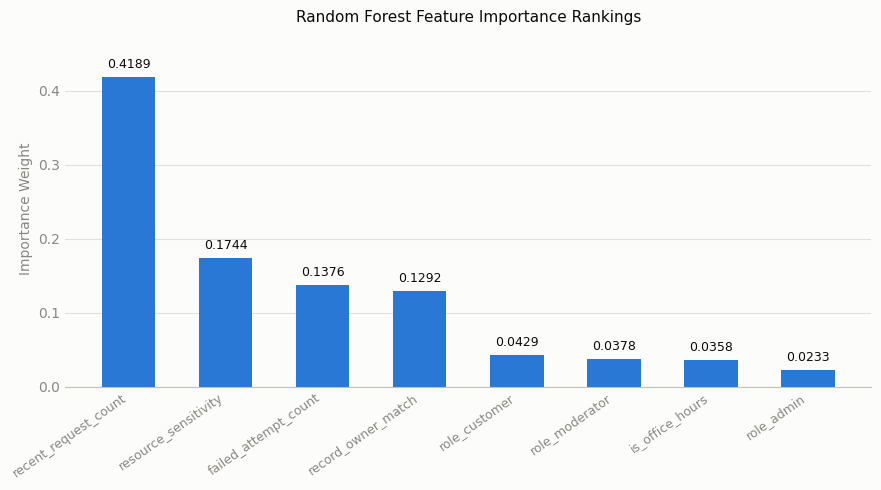

In [9]:
# ==========================================
# STEP 6: VISUALIZATION — FEATURE IMPORTANCE RANKINGS
# ==========================================
# Descending order so the most important feature comes first (left)
imp_sorted = importances.sort_values(by='Importance Weight', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

ax.bar(range(len(imp_sorted)), imp_sorted['Importance Weight'],
       width=0.55, color=BAR_BLUE)
for x, v in enumerate(imp_sorted['Importance Weight']):
    ax.text(x, v + 0.008, f"{v:.4f}", ha='center', va='bottom',
            color=INK, fontsize=9)

ax.set_xticks(range(len(imp_sorted)), imp_sorted['Feature'],
              fontsize=9, rotation=35, ha='right')
ax.set_ylim(0, imp_sorted['Importance Weight'].max() * 1.15)
ax.set_ylabel('Importance Weight', color=INK_MUTED)
ax.set_title('Random Forest Feature Importance Rankings', color=INK, fontsize=11)
ax.yaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(length=0, labelcolor=INK_MUTED)
for side in ['top', 'right', 'left']:
    ax.spines[side].set_visible(False)
ax.spines['bottom'].set_color(BASELINE)

plt.tight_layout()
plt.show()